In [33]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [25]:
df =pd.read_csv("data.csv")

print("\nClass Distribution :\n")
print(df["Decision"].value_counts())


Class Distribution :

Decision
Cinema      55
Shopping    15
Stay-in     15
Tennis      15
Name: count, dtype: int64


In [26]:
X = df.drop("Decision",axis=1)
y = df["Decision"]

In [27]:
categorical_features=["Weather","Parents","Money"]
preprocessor = ColumnTransformer(
    transformers=[
        ("cat",OneHotEncoder(handle_unknown='ignore'),categorical_features)
    ]
)

In [28]:
pipeline = Pipeline(steps=[
    ("preprocessing",preprocessor),
    ("model",DecisionTreeClassifier(
        criterion = "entropy",
        max_depth=3,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    ))
])

In [29]:
pipeline.fit(X,y)
print("\nTraining Accuracy:",pipeline.score(X,y))


Training Accuracy: 0.85


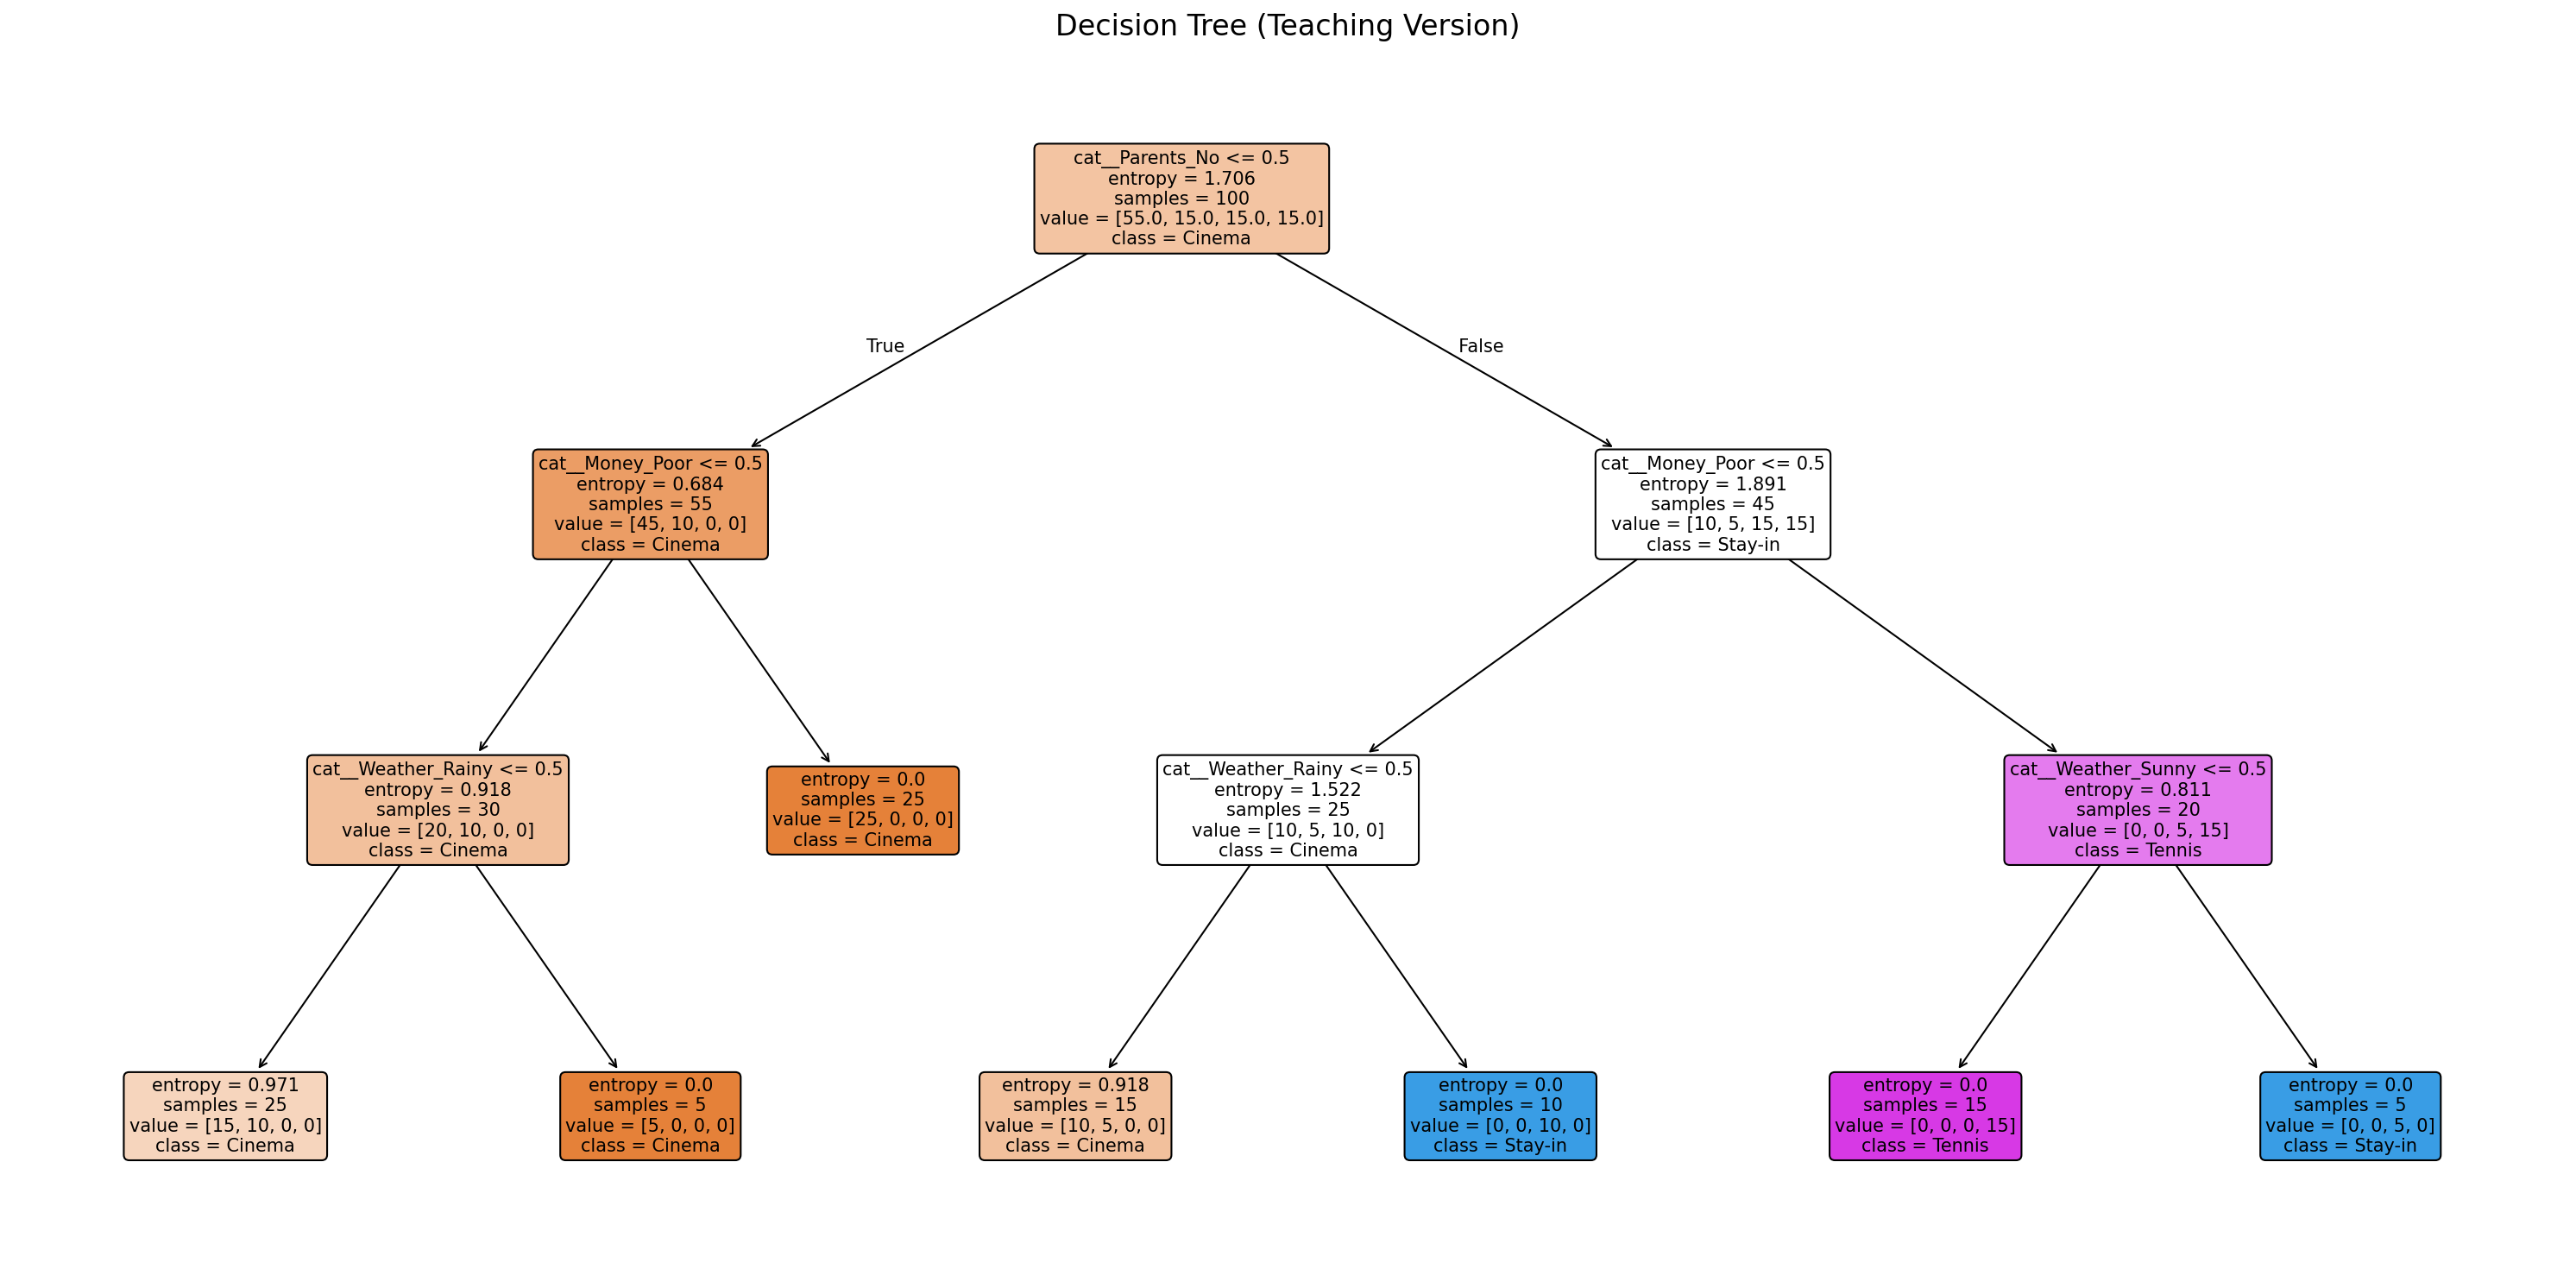

In [30]:
feature_names = pipeline.named_steps["preprocessing"].get_feature_names_out()

plt.figure(figsize=(20,10), dpi=150)

plot_tree(
    pipeline.named_steps["model"],
    feature_names=feature_names,
    class_names=pipeline.named_steps["model"].classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree (Teaching Version)",fontsize=16)
plt.tight_layout()
plt.savefig("clean_decision_tree.png",dpi=300)
plt.show()

In [31]:
def predict_user_input():
    print("\nEnter user Details:")
    weather =input("Weather(Sunny/Windly/Rainy): ")
    parent =input("Parent (Yes/No): ")
    money =input("Money(Rich/Poor): ")

    user_df = pd.DataFrame({
        "Weather":[weather],
        "Parents" :[parent],
        "Money"  :[money]
    })

    prediction =pipeline.predict(user_df)[0]
    probability = pipeline.predict_proba(user_df)

    print("\nPredicted Decision: ",prediction)
    print("Class Probabilities:")

    for cls,prob in zip(pipeline.named_steps["model"].classes_, probability[0]):
        print(f"{cls}: {round(prob*100,2)}%")

predict_user_input()


Enter user Details:


Weather(Sunny/Windly/Rainy):  rain
Parent (Yes/No):  no
Money(Rich/Poor):  rich



Predicted Decision:  Cinema
Class Probabilities:
Cinema: 60.0%
Shopping: 40.0%
Stay-in: 0.0%
Tennis: 0.0%


In [35]:
x = df.drop("Decision",axis=1)
Y = df["Decision"]

x_train, x_test , Y_train, Y_test = train_test_split(
    x,Y, test_size=0.2 ,random_state=42
)

In [37]:
pipeline.fit(X_train,y_train)
print("\nTraining Accuracy:",pipeline.score(x,Y))
pred = pipeline.predict(x_test)



Training Accuracy: 0.85


In [41]:
predict_user_input()


Enter user Details:


Weather(Sunny/Windly/Rainy):  rainny
Parent (Yes/No):  noo
Money(Rich/Poor):  poor



Predicted Decision:  Cinema
Class Probabilities:
Cinema: 57.14%
Shopping: 42.86%
Stay-in: 0.0%
Tennis: 0.0%
